# POD Frequency Sweep


The computation of the MPT coefficents at a single frequency requires the setting up and solving of a finite element problem (which we also refer to as the full order problem) and, if we want to get a MPT spectral signature, we would need to repeatabile solve the finite element problem for each frequency of interest. To get high fidelity MPT spectral signatures, this requires the use of large number of repeated full order solutions, which can become expensive if high order elements are used.

To reduce the computational cost of producing high fidelity spectral signatures the routine use of the Proper Orthogonal Decomposition (POD) reduced order model is recommended. This only requires the calculation of a small number of full order solutions (typically $N=13$) and is able to accurately predict the full MPT spectral signature at high-fidelity at much reduced cost.

We begin with the usual imports

In [1]:
from time import time
import numpy as np
from matplotlib import pyplot as plt
import os
root_dir = os.path.dirname(os.getcwd())
os.chdir(root_dir)

In [2]:
from runner import main
from time import time

We again consider the MPT characterisation of a conducting sphere with $\sigma_* =1  \times 10^6 $ S/m, $\mu_r=1$ and radius $\alpha =1 \times 10^{-3}$ m using the same default descretisation as in Tutorial ?? 

When using POD, the default settings are to have $N=13$ full order model solutions obtained at logarthmically spaced frequency snapshots and to extract model information based on a singular value decomposition using a tolerance of $TOL=$. Reduced order model solutions are then computed at 40 logarthmically spaced frequency snapshots with $ 1 \times 10 \le \omega \le 1 \times 10^8$ rad/s.

For the default problem, we specify that we wish to use POD as follows

sphere.geo
 mesh contains 3839 elements
 solved theta0 problems    
manually closed pool
 SVD complete                
manually closed poolder model
 reduced order systems solved          
 frequency sweep complete


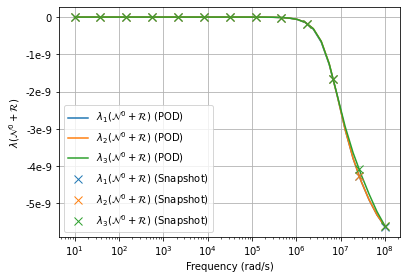

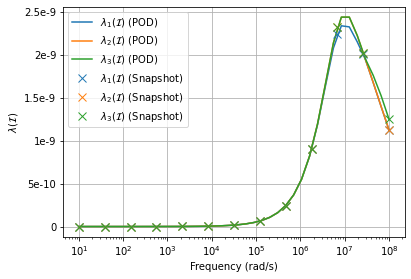

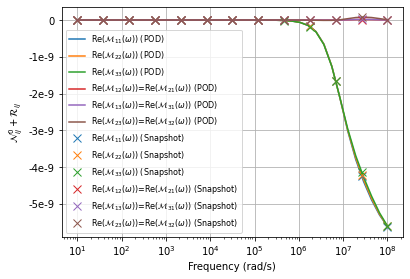

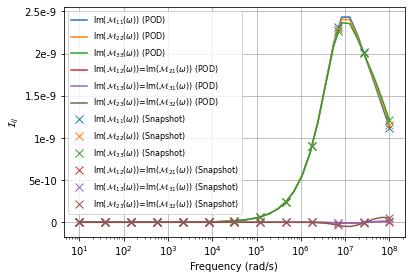

In [3]:
start_time = time();
main(use_POD=True);
stop_time = time();

In [4]:
print(f'Total time = {stop_time - start_time}')

Total time = 20.400984048843384


The graphs produced above show the POD solutions as continous lines with the snapshot (full order model solutions) indicated by crosses. The POD solutions pass through the full order model solutions as expected.

### Saving Results

The output of the simulation, including any figures, are saved in the `Results` subfolder of the root directory.

For example: 
```bash
Results/sphere/al_0.001_mu_1_sig_1e6/1e1-1e8_40_el_3839_ord_2_POD_13_1e-6
```

The results folder will contain a copy of the input files used for the simulation, including the mesh, .geo file, and a copy of the main function. This is so that the results can be recreated. The naming of the subfolders reflects

1. The `sphere` problem that has been solved
2. The object size and materials ($\alpha =1 \times 10^{-3}$ m, $\sigma_* =1  \times 10^6 $ S/m, $\mu_r=1$) by `al_0.001_mu_1_sig_1e6`
3. The frequency range, number of samples, number of elements and element order ($ 1 \times 10 \le \omega \le 1 \times 10^8$ rad/s, $N=40$ samples, 3 839 elements, $p=2$) by `1e1-1e8_40_el_3839_ord_2`

The computed POD solutions are stored 


An additional feature of the POD approach is the ability to produce error estimates of POD prediction of the MPT coefficents with respect to those that would be obtained with the full order model


INCLUDE EXAMPLE OF ERROR ESTIMATES